In [1]:
# %%
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Optional
from langgraph.checkpoint.sqlite import SqliteSaver
from dotenv import load_dotenv
from IPython.display import Image

In [ ]:
class EmailState(TypedDict):
    # --- Intake inputs ---
    input: str                 # raw user text/description
    client_snap_path: str      # client's reference screenshot
    embed_image_path: str      # PNG to embed in the email
    subject: str
    bcc: list[str]

    # --- Compose / review loop ---
    email_content: str         # generated HTML (the real payload)
    evaluate: Optional[Literal["pass", "failed"]]
    iteration: int             # current retry count
    max_iteration: int         # cap, e.g. 3

    # --- Human review ---
    human_decision: Optional[Literal["approve", "reject"]]

    # --- Publish ---   
    published: bool    

In [3]:
# STEP 1 — Intake
def intake(state: EmailState):
    # TODO: use ai/gemma4:E4B to read client_snap + input text,
    # extract subject/bcc/content sections via structured output (Pydantic)
    return {"subject": state.get("subject", ""), "bcc": state.get("bcc", [])}

# STEP 2 — Compose HTML
def compose_html(state: EmailState):
    # TODO: Jinja2 template + ai/llama3.2:3B fills content
    email_content = state["input"]  # placeholder passthrough for now
    return {"email_content": email_content}

# STEP 3 — Auto-review
def auto_review(state: EmailState):
    # TODO: ai/gemma4:E4B compares email_content vs client_snap, returns pass/failed
    return {"evaluate": "pass"}

def route_evaluation(state: EmailState):
    if state["evaluate"] == "pass" or state["iteration"] >= state["max_iteration"]:
        return "pass"
    return "failed"

# STEP 3b — Optimize (revise loop)
def optimize(state: EmailState):
    # TODO: regenerate email_content using auto_review's feedback
    return {
        "email_content": state["email_content"],  # placeholder
        "iteration": state["iteration"] + 1
    }

# STEP 4 — Test-send to human
def test_send_human(state: EmailState):
    # TODO: send email_content + client_snap to reviewer's inbox (tool call, no LLM)
    return {}

# STEP 5 — Human review (HITL)
def human_review(state: EmailState):
    # TODO: use interrupt() here to pause and wait for approve/reject
    return {"human_decision": "approve"}

def route_decision(state: EmailState):
    return "approve" if state["human_decision"] == "approve" else "reject"

# STEP 6/7 — Publish
def publish(state: EmailState):
    if state.get("published"):
        return {}  # idempotency guard
    # TODO: call Java publish API tool with final payload
    return {"published": True}

# STEP 8 — Manual fallback
def manual_handling(state: EmailState):
    # TODO: notify internal team, no automation yet
    return {}

def confirm_log(state: EmailState):
    # TODO: log final outcome
    return {}


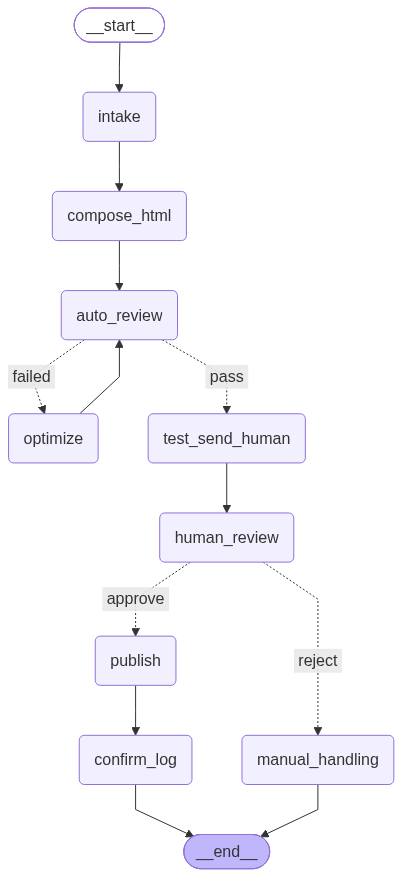

In [4]:
email_graph = StateGraph(EmailState)

email_graph.add_node("intake", intake)
email_graph.add_node("compose_html", compose_html)
email_graph.add_node("auto_review", auto_review)
email_graph.add_node("optimize", optimize)
email_graph.add_node("test_send_human", test_send_human)
email_graph.add_node("human_review", human_review)
email_graph.add_node("publish", publish)
email_graph.add_node("manual_handling", manual_handling)
email_graph.add_node("confirm_log", confirm_log)

email_graph.add_edge(START, "intake")
email_graph.add_edge("intake", "compose_html")
email_graph.add_edge("compose_html", "auto_review")
email_graph.add_conditional_edges(
    "auto_review", route_evaluation, {"pass": "test_send_human", "failed": "optimize"}
)
email_graph.add_edge("optimize", "auto_review")
email_graph.add_edge("test_send_human", "human_review")
email_graph.add_conditional_edges(
    "human_review", route_decision, {"approve": "publish", "reject": "manual_handling"}
)
email_graph.add_edge("publish", "confirm_log")
email_graph.add_edge("manual_handling", END)
email_graph.add_edge("confirm_log", END)

workflow = email_graph.compile()
workflow